

# Linear Programming: Allocation Models
### OPIM 5641 - Business Decision Modeling · Module 3
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/6_Pyomo_LP/1_Allocation_Models.ipynb)

*Run me top to bottom - **Runtime → Run all**. Pyomo and a solver install in the first cell.*

Related Readings:
* `Pyomo Cookbook`: https://github.com/jckantor/ND-Pyomo-Cookbook/blob/master/notebooks/02.01-Production-Models-with-Linear-Constraints.ipynb
* `Powell`: Chapter 9 (Linear Optimization)

## Background
The allocation model calls for maximizing an objective(usually profit) subject to less-than constraints on capacity.

🔷 **The nugget:** allocation models hand out a *limited resource* among competing uses - the `<=` constraints are your limits, the objective is what you're maximizing. Learn to spot this shape and you can model half the business problems you'll ever meet.

## Setup Your Environment/Imports

In [1]:
# import modules

%matplotlib inline
from pylab import *

import shutil
import sys
import os.path

if not shutil.which("pyomo"):
    !pip install -q pyomo
    assert(shutil.which("pyomo"))

if not (shutil.which("cbc") or os.path.isfile("cbc")):
    if "google.colab" in sys.modules:
        !apt-get install -y -qq coinor-cbc
    else:
        try:
            !conda install -c conda-forge coincbc 
        except:
            pass

assert(shutil.which("cbc") or os.path.isfile("cbc"))

from pyomo.environ import *

# Example: Furniture
*Section 9.2 (Powell) - Chairs, Desks and Tables*

**Problem Description:**
Veerman Furniture Company makes three kinds of office furniture: chairs, desks, and tables. Each product requires some labor in the parts fabrication department, the assembly department, and the shipping department. The furniture is sold through a regional distributor, who has estimated the maximum potential sales for each product in the coming quarter. Finally,the accounting department has provided some data showing the profit contributions on each product. The decision problem is to determine the product mix - that is, to maximize Veerman’s profit for the quarter by choosing production quantities for the chairs, desks, and tables.

The following data summarizes the parameters of the problem:

| Department | Chairs | Desks | Tables | Hours Available |
|---|---|---|---|---|
| Fabrication | 4 | 6 | 2 | 1,850 |
| Assembly | 3 | 5 | 7 | 2,400 |
| Shipping | 3 | 2 | 4 | 1,500 |
| **Demand Potential** | 360 | 300 | 100 | - |
| **Profit (USD)** | 15 | 24 | 18 | - |

**Define the Objective Function**

$Profit = 15C + 24D + 18T$

**Write the Constraints**

$Max(Z) = 15C + 24D + 18T$

subject to:
* $4C + 6D + 2T <= 1,850$
* $3C + 5D + 7T <= 2,400$
* $3C + 2D + 4T <= 1,500$ 
* $C        <= 360$ 
* $D      <=300$ 
* $T <=100$

Great! Now that your problem is defined - go code it up and solve it.

In [2]:
# declare the model
model = ConcreteModel()

# declare decision variables
model.c = Var(domain=NonNegativeReals) # c for chairs
model.d = Var(domain=NonNegativeReals) # d for desks
model.t = Var(domain=NonNegativeReals) # t for tables

# declare objective
model.profit = Objective(
                      expr = 15*model.c + 24*model.d + 18*model.t, # values come from the table
                      sense = maximize)

# declare constraints
model.Constraint1 = Constraint(expr = 4*model.c + 6*model.d + 2*model.t <= 1850) # fabrication hours
model.Constraint2 = Constraint(expr = 3*model.c + 5*model.d + 7*model.t <= 2400) # assembly hours
model.Constraint3 = Constraint(expr = 3*model.c + 2*model.d + 4*model.t <= 1500) # shipping
model.Constraint4 = Constraint(expr = model.c <= 360) # c demand
model.Constraint5 = Constraint(expr = model.d <= 300) # d demand
model.Constraint6 = Constraint(expr = model.t <= 100) # t demand

In [3]:
# show the model you've created
model.pprint()

3 Var Declarations
    c : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals
    d : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals
    t : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :  None :  None : False :  True : NonNegativeReals

1 Objective Declarations
    profit : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : 15*c + 24*d + 18*t

6 Constraint Declarations
    Constraint1 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper  : Active
        None :  -Inf : 4*c + 6*d + 2*t : 1850.0 :   True
    Constraint2 : Size=1, Index=None, Active=True
        Key  : Lower : Body            : Upper  : Active
        None :  -Inf : 3*c + 

In [4]:
# ensure you have cbc installed
# !apt-get install -y -qq coinor-cbc

In [5]:
# solve it
SolverFactory('cbc', executable='/usr/bin/cbc').solve(model).write()

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 8400.0
  Upper bound: 8400.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.0
  Wallclock time: 0.0
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created s

In [6]:
# show the results
print("Profit = ", model.profit(), " per week")
print("Chairs = ", model.c(), " units per week")
print("Desks = ", model.d(), " units per week")
print("Tables = ", model.t(), " units per week")

Profit =  8400.0  per week
Chairs =  0.0  units per week
Desks =  275.0  units per week
Tables =  100.0  units per week


# Binding Constraints
Let's see if any constraints are 'binding' (you use it all up!)

A binding constraint is where the LHS is equal to the RHS.

$Max(Z) = 15C + 24D + 18T$

subject to:
* $4C + 6D + 2T <= 1,850$ `[fabrication]`
* $3C + 5D + 7T <= 2,400$ `[assembly]`
* $3C + 2D + 4T <= 1,500$ `[shipping]` 
* $C        <= 360$ `[chair demand]`
* $D      <=300$  `[desk demand]`
* $T <=100$ `[table demand]`

In [7]:
print("Fabrication = ", model.Constraint1(), "hours")
print("Assembly = ", model.Constraint2(), "hours")
print("Shipping = ", model.Constraint3(), "hours")
print("Chairs = ", model.Constraint4(), " units per week")
print("Desks = ", model.Constraint5(), " units per week")
print("Tables = ", model.Constraint6(), " units per week")

Fabrication =  1850.0 hours
Assembly =  2075.0 hours
Shipping =  950.0 hours
Chairs =  0.0  units per week
Desks =  275.0  units per week
Tables =  100.0  units per week


<!-- oct8 -->
### LHS, RHS and slack, side by side

Printing the left-hand sides is a start, but it is much easier to spot a bottleneck when each constraint
sits next to its limit. The cell below makes a small table: what you **used** (LHS), the **limit** (RHS),
what is **left over** (slack = RHS - LHS), and a flag on the **binding** ones (slack = 0).

`value(c.upper)` reads the right-hand side of a `<=` constraint. For a `>=` constraint use `value(c.lower)`
instead, and the slack is LHS - RHS.

In [8]:
# LHS, RHS and slack side by side - the BINDING ones are the bottlenecks
import pandas as pd

names = ["Fabrication hours", "Assembly hours", "Shipping hours", "Chair demand", "Desk demand", "Table demand"]
constraints = [model.Constraint1, model.Constraint2, model.Constraint3, model.Constraint4, model.Constraint5, model.Constraint6]

report = pd.DataFrame()
for i in range(len(constraints)):
    c = constraints[i]
    lhs = c()                  # left-hand side: what the plan actually uses
    rhs = value(c.upper)       # right-hand side: the limit (all six are <= constraints)
    slack = rhs - lhs          # what is left over
    if slack < 0.000001:
        status = "BINDING"
    else:
        status = ""
    row = pd.DataFrame({"constraint": [names[i]], "LHS (used)": [lhs], "RHS (limit)": [rhs], "slack": [slack], "binding?": [status]})
    report = pd.concat([report, row])

report.reset_index(drop=True, inplace=True)
report

,constraint,LHS (used),RHS (limit),slack,binding?
0,Fabrication hours,1850.0,1850.0,0.0,BINDING
1,Assembly hours,2075.0,2400.0,325.0,
2,Shipping hours,950.0,1500.0,550.0,
3,Chair demand,0.0,360.0,360.0,
4,Desk demand,275.0,300.0,25.0,
5,Table demand,100.0,100.0,0.0,BINDING


# For Loop for 'Shadow Prices'
Linear programs typically give rise to a distinct pattern in sensitivity tables when we vary the availability of a scarce resource.The marginal value of capacity remains constant over some interval of increase or decrease. Within this interval, some of the decision variables change linearly with the change in capacity, while other decision variables stay the same.If someone were to continually give us more of a scarce resource,its value would drop and eventually fall to zero. In the case of our product mix problem,we could confirm that the value of additional hours drops to zero at a capacity level of 3,000. 

Let's check it out!


In [9]:
myHours = np.arange(1500,5000,100)
print(myHours)

[1500 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2800
 2900 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200
 4300 4400 4500 4600 4700 4800 4900]


In [10]:
# store the results
import pandas as pd
myResults = pd.DataFrame() # empty place to store results

for a in myHours:
  # declare the model
  model = ConcreteModel()

  # declare decision variables
  model.c = Var(domain=NonNegativeReals)
  model.d = Var(domain=NonNegativeReals)
  model.t = Var(domain=NonNegativeReals)

  # declare objective
  model.profit = Objective(
                        expr = 15*model.c + 24*model.d + 18*model.t, # values come from the table
                        sense = maximize)

  # declare constraints
  model.Constraint1 = Constraint(expr = 4*model.c + 6*model.d + 2*model.t <= a) # fabrication hours
  model.Constraint2 = Constraint(expr = 3*model.c + 5*model.d + 7*model.t <= 2400) # assembly hours
  model.Constraint3 = Constraint(expr = 3*model.c + 2*model.d + 4*model.t <= 1500) # shipping
  model.Constraint4 = Constraint(expr = model.c <= 360) # c demand
  model.Constraint5 = Constraint(expr = model.d <= 300) # d demand
  model.Constraint6 = Constraint(expr = model.t <= 100) # t demand

  # solve it
  SolverFactory('cbc', executable='/usr/bin/cbc').solve(model).write()

  # results
 
  myX = pd.DataFrame([a, model.profit(), model.c(), model.d(), model.t()])
  myX=myX.T # transpose

  # store the profit
  # NOTE: DataFrame.append was removed in pandas 2.0 - pd.concat replaces it
  myResults = pd.concat([myResults, myX])
 
# Change the Column names
myResults = myResults.rename( {0:"Fabrication Hours", 1:"Profit",2:"Chairs", 3:"Desks" ,4:"Tables"}, axis='columns') 
myResults.reset_index(drop=True, inplace=True)
print(myResults)

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 7000.0
  Upper bound: 7000.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 7400.0
  Upper bound: 7400.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 7800.0
  Upper bound: 7800.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 8200.0
  Upper bound: 8200.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 8600.0
  Upper bound: 8600.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 9000.0
  Upper bound: 9000.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 9375.0
  Upper bound: 9375.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 9750.0
  Upper bound: 9750.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 10077.27273
  Upper bound: 10077.27273
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 10309.09091
  Upper bound: 10309.09091
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 10540.90909
  Upper bound: 10540.90909
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 10772.72727
  Upper bound: 10772.72727
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11004.54545
  Upper bound: 11004.54545
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11236.36364
  Upper bound: 11236.36364
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11468.18182
  Upper bound: 11468.18182
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number 

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================


# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of created subproblems: None
    Black box: 
      Number of iteratio

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 11700.0
  Upper bound: 11700.0
  Number of objectives: 1
  Number of constraints: 6
  Number of variables: 3
  Number of nonzeros: 3
  Sense: maximize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.01
  Wallclock time: 0.01
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Statistics: 
    Branch and bound: 
      Number of bounded subproblems: None
      Number of creat

## Product Mix
Let's see how the product mix would change if we were able to increase the fabrication hours in increments of 100 hours. 

In [11]:
myResults

,Fabrication Hours,Profit,Chairs,Desks,Tables
0,1500.0,7000.000080,0.000000,216.66667,100.000000
1,1600.0,7399.999920,0.000000,233.33333,100.000000
2,1700.0,7800.000000,0.000000,250.00000,100.000000
3,1800.0,8200.000080,0.000000,266.66667,100.000000
4,1900.0,8599.999920,0.000000,283.33333,100.000000
5,2000.0,9000.000000,0.000000,300.00000,100.000000
6,2100.0,9375.000000,25.000000,300.00000,100.000000
7,2200.0,9750.000000,50.000000,300.00000,100.000000
8,2300.0,10077.272715,77.272727,300.00000,95.454545
9,2400.0,10309.090926,109.090910,300.00000,81.818182


<Axes: xlabel='Fabrication Hours'>

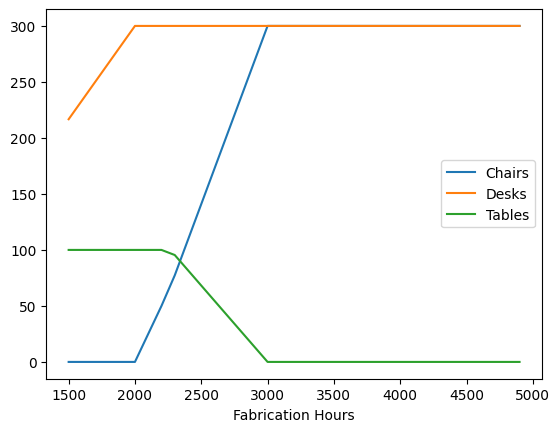

In [12]:
# make a nice plot
tmp = myResults.drop(['Profit'], axis=1)
tmp.plot(x='Fabrication Hours')

In [13]:
# add a column for marginal increase (per 100 hours)
myResults['ProfitDiff'] = myResults['Profit'].diff()

# if you wanted it by ONE HOUR
myResults['ProfitDiffOneHour'] = myResults['Profit'].diff()/myResults['Fabrication Hours'].diff()

# show the table
myResults

,Fabrication Hours,Profit,Chairs,Desks,Tables,ProfitDiff,ProfitDiffOneHour
0,1500.0,7000.000080,0.000000,216.66667,100.000000,NaN,NaN
1,1600.0,7399.999920,0.000000,233.33333,100.000000,399.999840,3.999998
2,1700.0,7800.000000,0.000000,250.00000,100.000000,400.000080,4.000001
3,1800.0,8200.000080,0.000000,266.66667,100.000000,400.000080,4.000001
4,1900.0,8599.999920,0.000000,283.33333,100.000000,399.999840,3.999998
5,2000.0,9000.000000,0.000000,300.00000,100.000000,400.000080,4.000001
6,2100.0,9375.000000,25.000000,300.00000,100.000000,375.000000,3.750000
7,2200.0,9750.000000,50.000000,300.00000,100.000000,375.000000,3.750000
8,2300.0,10077.272715,77.272727,300.00000,95.454545,327.272715,3.272727
9,2400.0,10309.090926,109.090910,300.00000,81.818182,231.818211,2.318182


## Profit and Diminishing Returns
Recall that we are looking at fabrication hours...

If you a scarce resource becomes 'unlimited' its value becomes ZERO! Amazing.

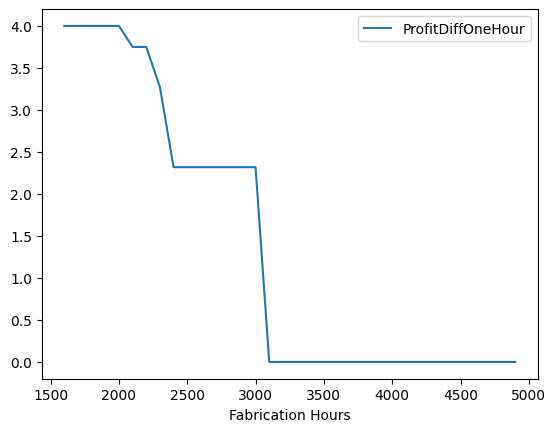

In [14]:
# make a nice plot
tmp = myResults.drop(['Profit','Chairs','Desks','Tables'], axis=1)
tmp.plot(x='Fabrication Hours', y='ProfitDiffOneHour')
plt.show()

<!-- oct8 -->
## The profit curve, next to the shadow price

Here are the two pictures side by side. The red line is where we started: **1,850 fabrication hours**.

- **Left:** profit climbs as you add hours, then **plateaus**. Past that point more hours buy you nothing.
- **Right:** the value of one more hour (the shadow price). It is the **slope** of the left plot: steep
  slope = high shadow price, flat = \$0.

Read them together: the profit curve flattens out at exactly the hours where the shadow price drops to \$0.
That is diminishing returns, and it tells you how many extra hours are worth paying for.

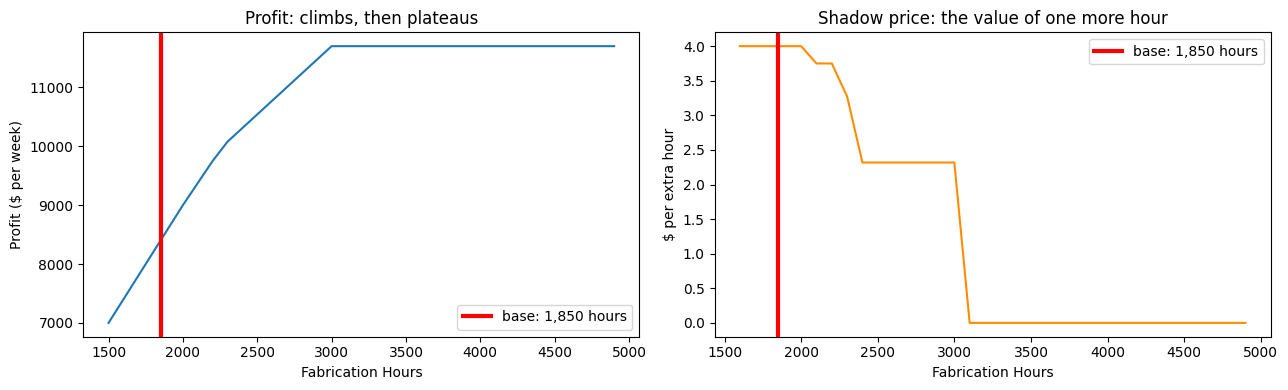

In [15]:
# the profit curve and the shadow price, side by side
base_hours = 1850     # the fabrication hours in the original problem

fig, axes = subplots(1, 2, figsize=(13, 4))

axes[0].plot(myResults['Fabrication Hours'], myResults['Profit'])
axes[0].axvline(base_hours, color='red', linewidth=3, label='base: 1,850 hours')
axes[0].set_xlabel('Fabrication Hours')
axes[0].set_ylabel('Profit ($ per week)')
axes[0].set_title('Profit: climbs, then plateaus')
axes[0].legend()

axes[1].plot(myResults['Fabrication Hours'], myResults['ProfitDiffOneHour'], color='darkorange')
axes[1].axvline(base_hours, color='red', linewidth=3, label='base: 1,850 hours')
axes[1].set_xlabel('Fabrication Hours')
axes[1].set_ylabel('$ per extra hour')
axes[1].set_title('Shadow price: the value of one more hour')
axes[1].legend()

tight_layout()
show()

## Bottom line

Allocation is the workhorse LP: maximize value subject to resource limits. Same Pyomo skeleton, new story. **Take it further:** add a new product or a new resource constraint and watch the optimal mix shift.